✅ All seeds set to 42 - Results will be 100% reproducible
🚀 OPTIMIZED PARKINSON'S DISEASE DETECTION SYSTEM
📍 Using device: cpu
📍 Output directory: pd_optimized_results

🚀 STARTING OPTIMIZED PIPELINE

[1/5] Loading data...

📁 Scanning: E:\miniproject\PD

✅ Found 3400 files
   PD: 1700 | Healthy: 1700

[2/5] Extracting features...


   Processing: 100%|██████████| 3400/3400 [02:24<00:00, 23.48files/s]



   ✅ Extracted: 3400 files
   ❌ Failed: 0 files
   📊 Feature dimension: 26

[3/5] Splitting data...

   📊 Final split:
      Train: 2380 samples
      Validation: 340 samples
      Test: 680 samples

[4/5] Scaling features...

[5/5] Training model...
      Epoch 10: Train Acc = 76.64%, Val Acc = 82.65%
      Epoch 20: Train Acc = 82.10%, Val Acc = 84.12%
      Epoch 30: Train Acc = 85.55%, Val Acc = 85.00%
      Epoch 40: Train Acc = 87.23%, Val Acc = 87.06%
      Epoch 50: Train Acc = 88.70%, Val Acc = 86.76%

   ✅ Best validation accuracy: 88.24%

📊 Final evaluation on test set...

📊 FINAL TEST SET RESULTS

🎯 Accuracy:  87.94%
🎯 UAR:       87.94%
🎯 Precision: 89.09%
🎯 Recall:    86.47%
🎯 F1-Score:  0.8776
🎯 Specificity: 89.41%
🎯 Kappa:     0.7588
🎯 MCC:       0.7592
🎯 ROC-AUC:   0.9480

📊 Confusion Matrix:
               Predicted
               Healthy  PD
Actual Healthy   304     36
       PD         46    294

📈 Generating plots...


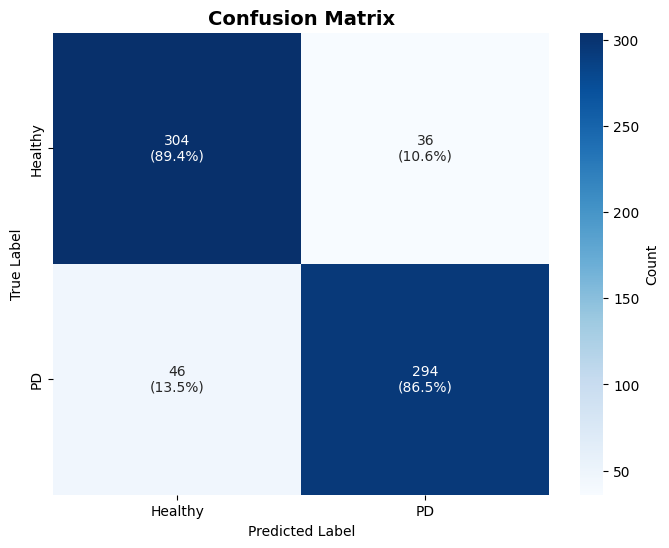

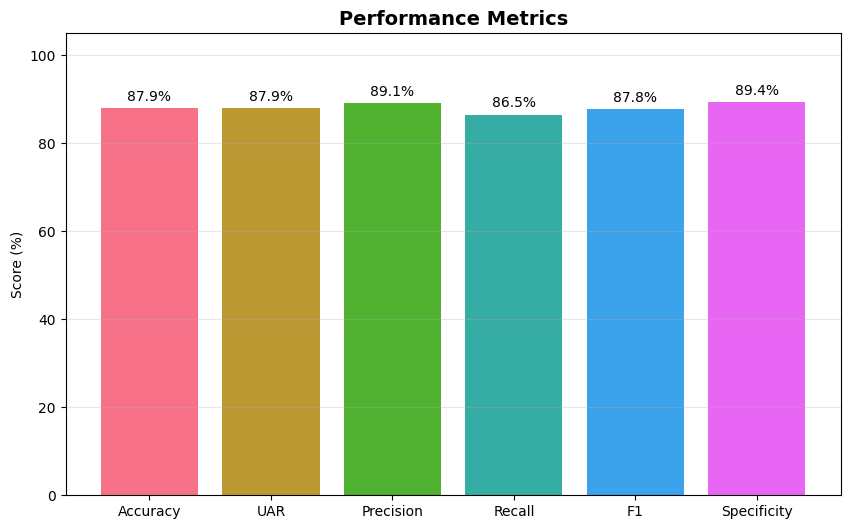


✅ PIPELINE COMPLETED SUCCESSFULLY!

📁 Results saved to: pd_optimized_results/
⏱️  Total time: 2.79 minutes

🎯 Final Accuracy: 87.94%


In [ ]:
# ============================================
# IMPORTS
# ============================================
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import soundfile as sf
import librosa
import pywt
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix,
                            classification_report, cohen_kappa_score,
                            matthews_corrcoef, balanced_accuracy_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import pickle
import time
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import math
import gc


def set_all_seeds(seed=42):
    """Set all random seeds for perfect reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # For sklearn
    from sklearn.utils import check_random_state
    check_random_state(seed)
    
    print(f"✅ All seeds set to {seed} - Results will be 100% reproducible")

set_all_seeds(42)

print("="*90)
print("🚀 OPTIMIZED PARKINSON'S DISEASE DETECTION SYSTEM")
print("="*90)

# ============================================
# CONFIGURATION
# ============================================
BASE_PATH = r"E:\miniproject\PD"
OUTPUT_DIR = "pd_optimized_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "graphs"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "models"), exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"📍 Using device: {device}")
print(f"📍 Output directory: {OUTPUT_DIR}")

class Config:
    TARGET_SR = 16000
    DURATION = 3
    N_MFCC = 20
    BATCH_SIZE = 32
    LEARNING_RATE = 0.001
    EPOCHS = 50
    TEST_SIZE = 0.2
    VAL_SIZE = 0.1

config = Config()

# ============================================
# DATA LOADER
# ============================================
def load_data(base_path):
    """Fast data loading without pandas overhead"""
    base_path = Path(base_path)
    file_list = []
    
    vowels = ['A', 'E', 'I', 'O', 'U', 'apto', 'petaka']
    conditions = ['Healthy', 'PD']
    
    print(f"\n📁 Scanning: {base_path}")
    
    for vowel in vowels:
        vowel_path = base_path / vowel
        if not vowel_path.exists():
            continue
        
        for condition in conditions:
            condition_path = vowel_path / condition
            if not condition_path.exists():
                continue
            
            wav_files = list(condition_path.glob('*.wav')) + list(condition_path.glob('*.WAV'))
            
            for wav_file in wav_files:
                file_list.append({
                    'path': str(wav_file),
                    'label': 1 if condition == 'PD' else 0,
                    'vowel': vowel
                })
    
    print(f"\n✅ Found {len(file_list)} files")
    
    # Quick stats
    pd_count = sum(1 for f in file_list if f['label'] == 1)
    healthy_count = len(file_list) - pd_count
    print(f"   PD: {pd_count} | Healthy: {healthy_count}")
    
    return file_list

def extract_features_fast(file_path):
    """Extract features quickly - 26 features"""
    try:
        # Load audio
        signal, sr = sf.read(file_path)
        
        # Convert to mono
        if len(signal.shape) > 1:
            signal = np.mean(signal, axis=1)
        
        # Resample to 16kHz
        if sr != config.TARGET_SR:
            signal = librosa.resample(signal, orig_sr=sr, target_sr=config.TARGET_SR)
        
        # Normalize
        signal = signal / (np.max(np.abs(signal)) + 1e-8)
        
        # Fix duration
        target_len = config.TARGET_SR * config.DURATION
        if len(signal) > target_len:
            signal = signal[:target_len]
        else:
            signal = np.pad(signal, (0, target_len - len(signal)))
        
        features = []
        
        # 1. Statistical features (8)
        features.append(float(np.mean(signal)))
        features.append(float(np.std(signal)))
        features.append(float(np.var(signal)))
        features.append(float(stats.skew(signal)))
        features.append(float(stats.kurtosis(signal)))
        features.append(float(np.sqrt(np.mean(signal**2))))  # RMS
        features.append(float(np.ptp(signal)))  # Peak-to-peak
        features.append(float(np.sum(signal**2)))  # Energy
        
        # 2. Wavelet features (5)
        try:
            coeffs = pywt.wavedec(signal, 'db4', level=3)
            for i, c in enumerate(coeffs[:4]):
                if len(c) > 0:
                    features.append(float(np.sum(c**2) / len(c)))
                else:
                    features.append(0.0)
            
            # Wavelet entropy
            energies = [np.sum(c**2) for c in coeffs if len(c) > 0]
            total_energy = sum(energies)
            if total_energy > 0:
                probs = [e/total_energy for e in energies]
                entropy = -sum(p * np.log2(p + 1e-10) for p in probs)
                features.append(float(entropy))
            else:
                features.append(0.0)
        except:
            features.extend([0.0] * 5)
        
        # 3. MFCC features (10)
        try:
            mfccs = librosa.feature.mfcc(y=signal, sr=config.TARGET_SR, n_mfcc=5)
            for i in range(5):
                features.append(float(np.mean(mfccs[i])))
                features.append(float(np.std(mfccs[i])))
        except:
            features.extend([0.0] * 10)
        
        # 4. Entropy (1)
        try:
            hist, _ = np.histogram(signal, bins=50)
            probs = hist / np.sum(hist)
            probs = probs[probs > 0]
            features.append(float(-np.sum(probs * np.log2(probs))))
        except:
            features.append(0.0)
        
        # 5. Spectral features (2)
        try:
            # Spectral centroid
            centroid = librosa.feature.spectral_centroid(y=signal, sr=config.TARGET_SR)
            features.append(float(np.mean(centroid)))
            
            # Zero crossing rate
            zcr = librosa.feature.zero_crossing_rate(signal)
            features.append(float(np.mean(zcr)))
        except:
            features.extend([0.0, 0.0])
        
        return np.array(features, dtype=np.float32)
        
    except Exception as e:
        return None

# ============================================
# SIMPLE NEURAL NETWORK
# ============================================
class SimplePDNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )
    
    def forward(self, x):
        return self.net(x)

# ============================================
# METRICS CALCULATOR
# ============================================
def calculate_metrics(y_true, y_pred, y_proba=None):
    """Calculate all metrics"""
    metrics = {}
    
    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['balanced_accuracy'] = balanced_accuracy_score(y_true, y_pred)
    metrics['precision'] = precision_score(y_true, y_pred, average='binary', zero_division=0)
    metrics['recall'] = recall_score(y_true, y_pred, average='binary', zero_division=0)
    metrics['f1'] = f1_score(y_true, y_pred, average='binary', zero_division=0)
    metrics['uar'] = recall_score(y_true, y_pred, average='macro', zero_division=0)
    
    cm = confusion_matrix(y_true, y_pred)
    metrics['confusion_matrix'] = cm
    
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        metrics['specificity'] = tn / (tn + fp) if (tn + fp) > 0 else 0
        metrics['sensitivity'] = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    metrics['cohen_kappa'] = cohen_kappa_score(y_true, y_pred)
    metrics['mcc'] = matthews_corrcoef(y_true, y_pred)
    
    if y_proba is not None:
        try:
            metrics['roc_auc'] = roc_auc_score(y_true, y_proba[:, 1])
        except:
            metrics['roc_auc'] = 0.5
    
    return metrics

# ============================================
# TRAIN FUNCTION
# ============================================
def train_model(X_train, y_train, X_val, y_val, input_dim):
    """Train neural network"""
    
    # Create data loaders
    train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
    val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
    
    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE)
    
    # Initialize model
    model = SimplePDNet(input_dim).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RATE)
    
    best_val_acc = 0
    best_state = None
    
    for epoch in range(config.EPOCHS):
        # Training
        model.train()
        train_correct = 0
        train_total = 0
        
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            _, predicted = output.max(1)
            train_total += target.size(0)
            train_correct += predicted.eq(target).sum().item()
        
        train_acc = 100. * train_correct / train_total
        
        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                _, predicted = output.max(1)
                val_total += target.size(0)
                val_correct += predicted.eq(target).sum().item()
        
        val_acc = 100. * val_correct / val_total
        
        if (epoch + 1) % 10 == 0:
            print(f"      Epoch {epoch+1}: Train Acc = {train_acc:.2f}%, Val Acc = {val_acc:.2f}%")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict().copy()
    
    if best_state:
        model.load_state_dict(best_state)
    
    return model, best_val_acc

# ============================================
# PLOTTING FUNCTIONS
# ============================================
def plot_confusion_matrix(cm, save_path=None):
    """Plot confusion matrix"""
    plt.figure(figsize=(8, 6))
    
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    annot = np.empty_like(cm).astype(str)
    for i in range(2):
        for j in range(2):
            annot[i, j] = f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)'
    
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
                xticklabels=['Healthy', 'PD'],
                yticklabels=['Healthy', 'PD'],
                cbar_kws={'label': 'Count'})
    
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_metrics(metrics, save_path=None):
    """Plot metrics"""
    plt.figure(figsize=(10, 6))
    
    keys = ['Accuracy', 'UAR', 'Precision', 'Recall', 'F1', 'Specificity']
    values = [
        metrics['accuracy'] * 100,
        metrics['uar'] * 100,
        metrics['precision'] * 100,
        metrics['recall'] * 100,
        metrics['f1'] * 100,
        metrics.get('specificity', 0) * 100
    ]
    
    bars = plt.bar(keys, values, color=sns.color_palette("husl", 6))
    
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
    
    plt.title('Performance Metrics', fontsize=14, fontweight='bold')
    plt.ylabel('Score (%)')
    plt.ylim(0, 105)
    plt.grid(axis='y', alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# ============================================
# MAIN PIPELINE
# ============================================
def main():
    print("\n" + "="*90)
    print("🚀 STARTING OPTIMIZED PIPELINE")
    print("="*90)
    
    start_time = time.time()
    
    # Step 1: Load data
    print("\n[1/5] Loading data...")
    file_list = load_data(BASE_PATH)
    
    # Step 2: Extract features with progress bar
    print("\n[2/5] Extracting features...")
    features_list = []
    labels_list = []
    vowel_list = []
    failed = 0
    
    # Use tqdm for progress bar
    for file_info in tqdm(file_list, desc="   Processing", unit="files"):
        features = extract_features_fast(file_info['path'])
        if features is not None:
            features_list.append(features)
            labels_list.append(file_info['label'])
            vowel_list.append(file_info['vowel'])
        else:
            failed += 1
    
    X = np.array(features_list)
    y = np.array(labels_list)
    vowels = np.array(vowel_list)
    
    print(f"\n   ✅ Extracted: {len(features_list)} files")
    print(f"   ❌ Failed: {failed} files")
    print(f"   📊 Feature dimension: {X.shape[1]}")
    
    # Step 3: Split data
    print("\n[3/5] Splitting data...")
    
    # First split: train+val vs test
    X_temp, X_test, y_temp, y_test, v_temp, v_test = train_test_split(
        X, y, vowels, test_size=config.TEST_SIZE, random_state=42, stratify=y
    )
    
    # Second split: train vs val
    X_train, X_val, y_train, y_val, v_train, v_val = train_test_split(
        X_temp, y_temp, v_temp, test_size=config.VAL_SIZE/(1-config.TEST_SIZE), 
        random_state=42, stratify=y_temp
    )
    
    print(f"\n   📊 Final split:")
    print(f"      Train: {len(X_train)} samples")
    print(f"      Validation: {len(X_val)} samples")
    print(f"      Test: {len(X_test)} samples")
    
    # Step 4: Scale features
    print("\n[4/5] Scaling features...")
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    # Step 5: Train model
    print("\n[5/5] Training model...")
    model, best_val_acc = train_model(X_train_scaled, y_train, X_val_scaled, y_val, X.shape[1])
    print(f"\n   ✅ Best validation accuracy: {best_val_acc:.2f}%")
    
    # Final evaluation
    print("\n📊 Final evaluation on test set...")
    
    model.eval()
    with torch.no_grad():
        X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
        output = model(X_test_tensor)
        probs = F.softmax(output, dim=1)
        _, predictions = output.max(1)
        
        y_pred = predictions.cpu().numpy()
        y_proba = probs.cpu().numpy()
    
    metrics = calculate_metrics(y_test, y_pred, y_proba)
    
    print("\n" + "="*90)
    print("📊 FINAL TEST SET RESULTS")
    print("="*90)
    print(f"\n🎯 Accuracy:  {metrics['accuracy']*100:.2f}%")
    print(f"🎯 UAR:       {metrics['uar']*100:.2f}%")
    print(f"🎯 Precision: {metrics['precision']*100:.2f}%")
    print(f"🎯 Recall:    {metrics['recall']*100:.2f}%")
    print(f"🎯 F1-Score:  {metrics['f1']:.4f}")
    print(f"🎯 Specificity: {metrics.get('specificity',0)*100:.2f}%")
    print(f"🎯 Kappa:     {metrics['cohen_kappa']:.4f}")
    print(f"🎯 MCC:       {metrics['mcc']:.4f}")
    print(f"🎯 ROC-AUC:   {metrics.get('roc_auc',0):.4f}")
    
    # Confusion matrix
    cm = metrics['confusion_matrix']
    print(f"\n📊 Confusion Matrix:")
    print(f"               Predicted")
    print(f"               Healthy  PD")
    print(f"Actual Healthy   {cm[0,0]:3d}    {cm[0,1]:3d}")
    print(f"       PD        {cm[1,0]:3d}    {cm[1,1]:3d}")
    
    # Generate plots
    print("\n📈 Generating plots...")
    plot_confusion_matrix(cm, os.path.join(OUTPUT_DIR, 'graphs', 'confusion_matrix.png'))
    plot_metrics(metrics, os.path.join(OUTPUT_DIR, 'graphs', 'metrics.png'))
    
    # Save results
    results = {
        'metrics': metrics,
        'feature_shape': X.shape,
        'train_size': len(X_train),
        'val_size': len(X_val),
        'test_size': len(X_test),
        'total_time': time.time() - start_time
    }
    
    with open(os.path.join(OUTPUT_DIR, 'results.pkl'), 'wb') as f:
        pickle.dump(results, f)
    
    torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, 'models', 'model.pth'))
    
    print("\n" + "="*90)
    print("✅ PIPELINE COMPLETED SUCCESSFULLY!")
    print("="*90)
    print(f"\n📁 Results saved to: {OUTPUT_DIR}/")
    print(f"⏱️  Total time: {(time.time()-start_time)/60:.2f} minutes")
    
    return metrics

# ============================================
# RUN
# ============================================
if __name__ == "__main__":
    # Clear memory
    gc.collect()
    
    # Run pipeline
    results = main()
    
    print(f"\n🎯 Final Accuracy: {results['accuracy']*100:.2f}%")